In [1]:
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/London/enriched/listing_master.csv")

## 4.1 Statistics Summary

In [4]:
numeric_cols = [
    "price_clean",
    "bedrooms",
    "bathrooms",
    "accommodates",
    "number_of_reviews",
    "review_scores_rating",
    "availability_365",
    "occupancy_rate",
    "estimated_revenue",
    "host_tenure_years",
    "price_per_bedroom"
]

In [7]:
summary_stats = (
    df[numeric_cols]
    .describe()
    .T
)

summary_stats["missing_pct"] = (
    df[numeric_cols]
    .isna()
    .mean() * 100
)


summary_stats

,count,mean,std,min,25%,50%,75%,max,missing_pct
price_clean,61963.0,229.916983,4437.589296,7.000000,77.00000,135.000000,221.00,1085147.00,36.035552
bedrooms,84096.0,1.607092,1.040425,0.000000,1.00000,1.000000,2.00,50.00,13.187641
bathrooms,96871.0,1.227653,0.601455,0.000000,1.00000,1.000000,1.00,26.00,0.000000
accommodates,96871.0,3.326228,2.078605,1.000000,2.00000,2.000000,4.00,16.00,0.000000
number_of_reviews,96871.0,21.657627,50.368644,0.000000,1.00000,5.000000,20.00,1902.00,0.000000
review_scores_rating,72749.0,4.684719,0.494191,0.000000,4.58000,4.830000,5.00,5.00,24.901157
availability_365,96871.0,144.927429,141.808279,0.000000,0.00000,96.000000,288.00,365.00,0.000000
occupancy_rate,96871.0,60.280249,38.851356,0.000000,21.09589,73.698630,100.00,100.00,0.000000
estimated_revenue,61963.0,29016.264529,108702.622164,0.000000,3760.00000,14304.000000,34496.00,13486200.00,36.035552
host_tenure_years,96830.0,8.411565,3.893562,0.780000,4.83000,9.340000,11.35,17.82,0.042324


## Price Distribution

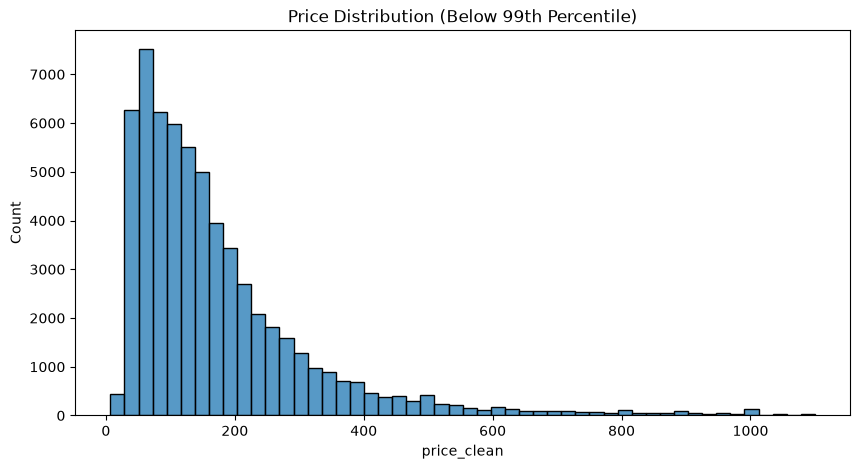

In [29]:
# Overall Price Distribution

price_99 = df["price_clean"].quantile(0.99)

price_plot = df[
    df["price_clean"] <= price_99
]

plt.figure(figsize=(10,5))

sns.histplot(
    price_plot["price_clean"],
    bins=50
)

plt.title(
    "Price Distribution (Below 99th Percentile)"
)

plt.show()

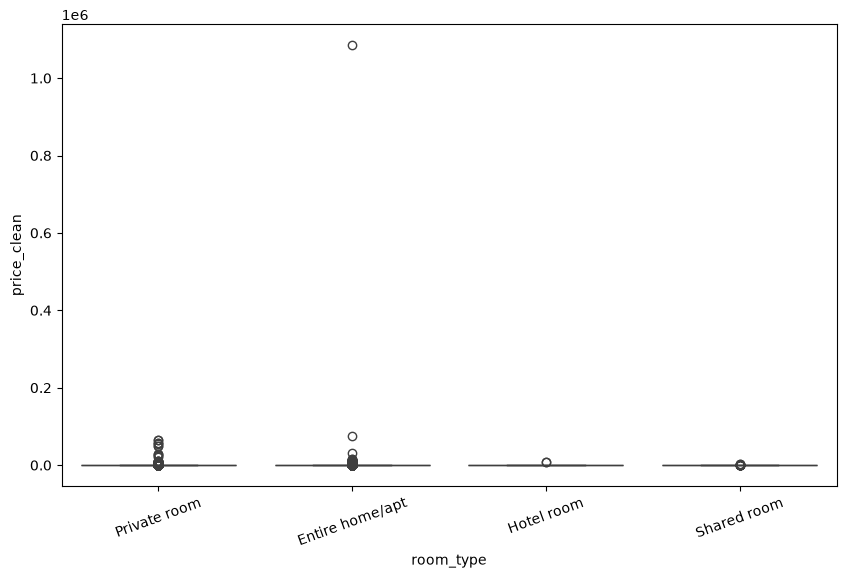

In [ ]:
# Boxplot by Room Type

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="room_type",
    y="price_clean"
)

plt.xticks(rotation=20)
plt.show()

In [10]:
# Average Price by Room Type

(
    df.groupby("room_type")
    ["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

room_type
Hotel room         657.833333
Entire home/apt    279.347157
Private room       121.713910
Shared room         96.910995
Name: price_clean, dtype: float64

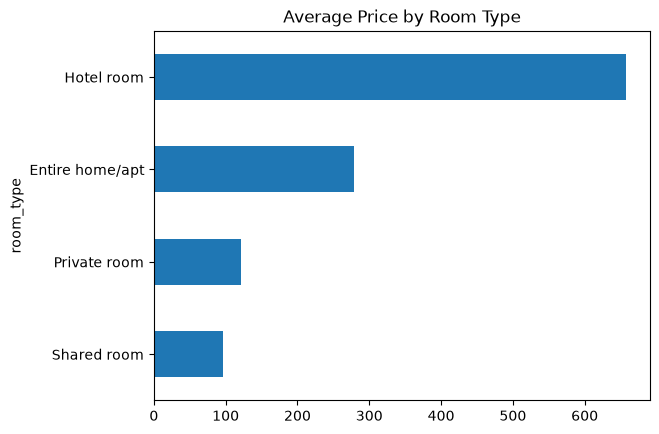

In [11]:
(
    df.groupby("room_type")
    ["price_clean"]
    .mean()
    .sort_values()
    .plot(kind="barh")
)

plt.title("Average Price by Room Type")
plt.show()

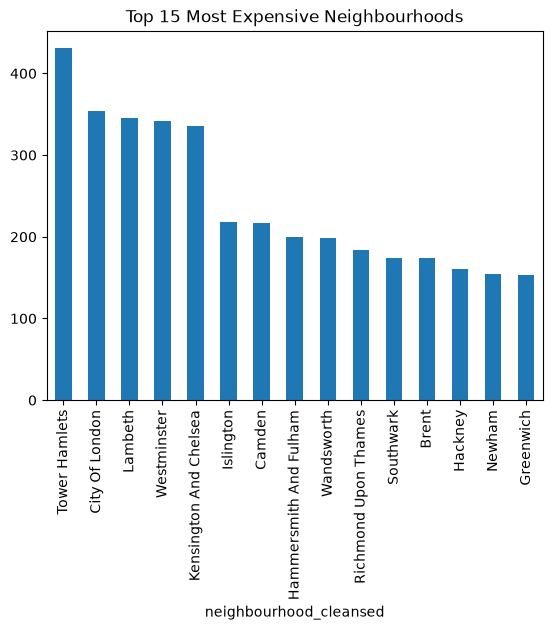

In [13]:
# Top 15 Neighbourhoods by Average Price

neighbourhood_price = (
    df.groupby("neighbourhood_cleansed")
    ["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

neighbourhood_price.plot(
    kind="bar"
)

plt.title(
    "Top 15 Most Expensive Neighbourhoods"
)

plt.show()

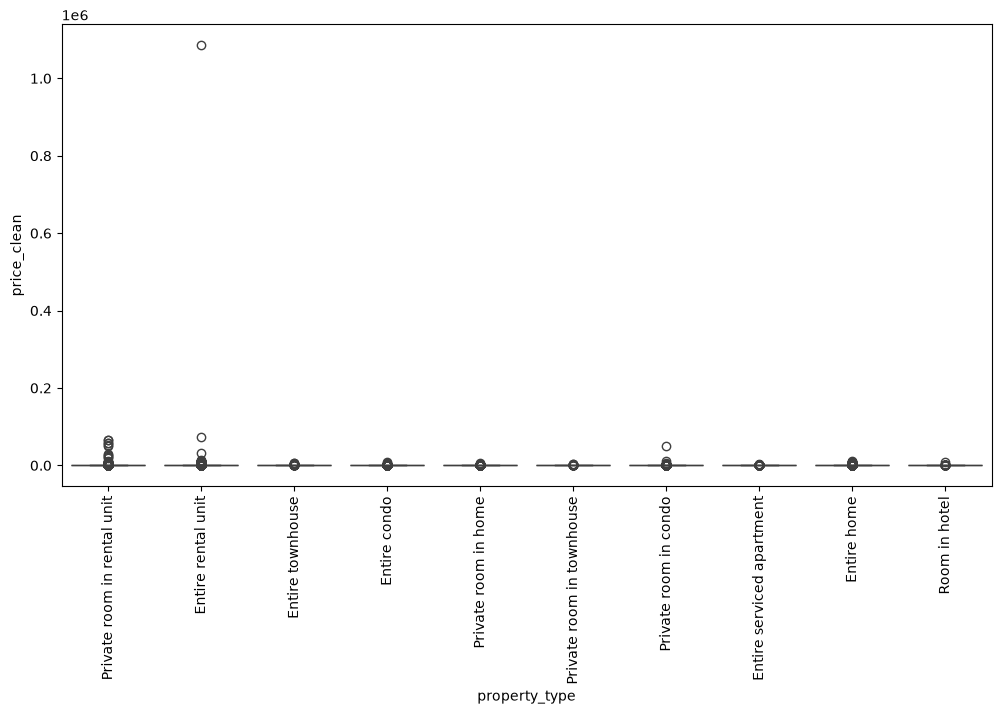

In [14]:
# Property Type Analysis

top_properties = (
    df["property_type"]
    .value_counts()
    .head(10)
    .index
)

property_df = (
    df[
        df["property_type"]
        .isin(top_properties)
    ]
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=property_df,
    x="property_type",
    y="price_clean"
)

plt.xticks(rotation=90)
plt.show()

## Listings Per Host (Power Law)

In [15]:
# Listings Per Host

host_counts = (
    df.groupby("host_id")
    .size()
)

host_counts.describe()

count    55646.000000
mean         1.740844
std          5.100665
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        500.000000
dtype: float64

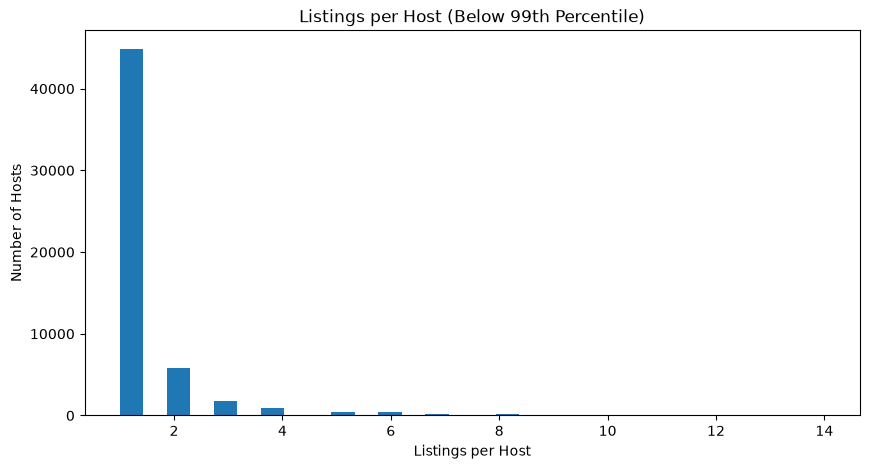

In [30]:
host_limit = host_counts.quantile(0.99)

host_counts_plot = host_counts[
    host_counts <= host_limit
]

plt.figure(figsize=(10,5))

plt.hist(
    host_counts_plot,
    bins=30
)

plt.title(
    "Listings per Host (Below 99th Percentile)"
)

plt.xlabel("Listings per Host")
plt.ylabel("Number of Hosts")

plt.show()

In [17]:
host_counts.sort_values(
    ascending=False
).head(20)

host_id
446820235    500
314162972    405
28820321     277
1432477      252
156158778    214
33889201     210
228928499    139
185324181    138
124359784    126
83740964     121
569524331    119
439074505    116
30253178     113
74167394     109
509948385    109
215357262    108
89355192     104
538103588    103
678046097    101
9063235       98
dtype: int64

In [18]:
# Commercial vs Casual Hosts

host_segment = pd.cut(
    host_counts,
    bins=[0,1,5,20,1000],
    labels=[
        "Single Listing",
        "Small Portfolio",
        "Professional",
        "Commercial"
    ]
)

host_segment.value_counts()

Single Listing     44875
Small Portfolio     8964
Professional        1486
Commercial           321
Name: count, dtype: int64

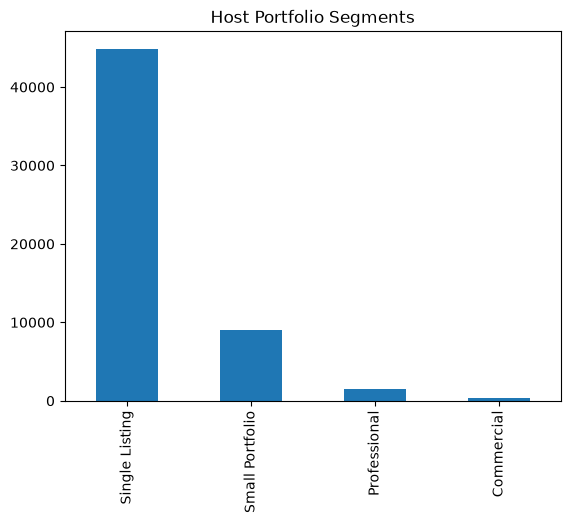

In [19]:
host_segment.value_counts().plot(
    kind="bar"
)

plt.title(
    "Host Portfolio Segments"
)

plt.show()

## Review Score Distribution

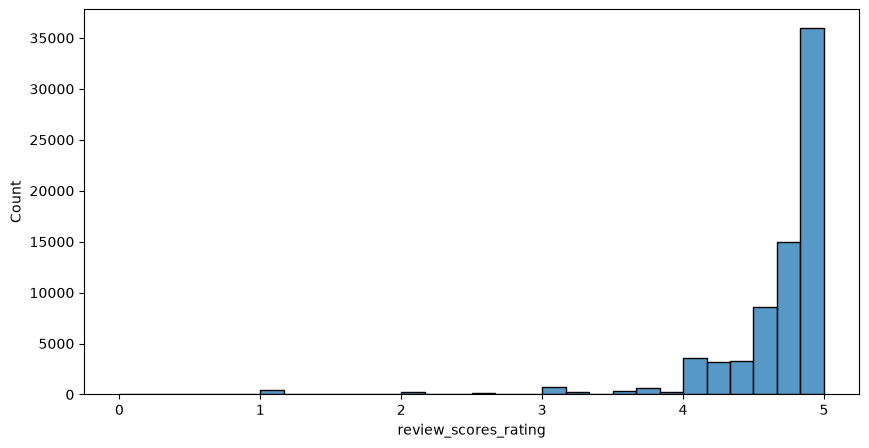

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["review_scores_rating"],
    bins=30
)

plt.show()

In [22]:
df["review_scores_rating"].describe()

count    72749.000000
mean         4.684719
std          0.494191
min          0.000000
25%          4.580000
50%          4.830000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

In [ ]:
(
    df["review_scores_rating"] >= 4.5  # above 4.5
).mean() * 100

np.float64(61.51479803037029)

In [ ]:
(
    df["review_scores_rating"] >= 4.8  # above 4.8
).mean() * 100

np.float64(41.78133806815249)

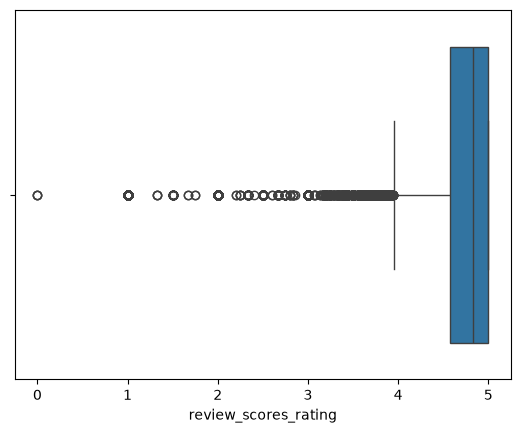

In [25]:
sns.boxplot(
    x=df["review_scores_rating"]
)

plt.show()

## Availability Analysis

In [26]:
availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

df[availability_cols].describe()

,availability_30,availability_60,availability_90,availability_365
count,96871.000000,96871.000000,96871.000000,96871.000000
mean,9.384295,22.261771,36.152120,144.927429
std,11.054524,23.205238,35.833903,141.808279
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,4.000000,15.000000,29.000000,96.000000
75%,18.000000,45.000000,73.000000,288.000000
max,30.000000,60.000000,90.000000,365.000000


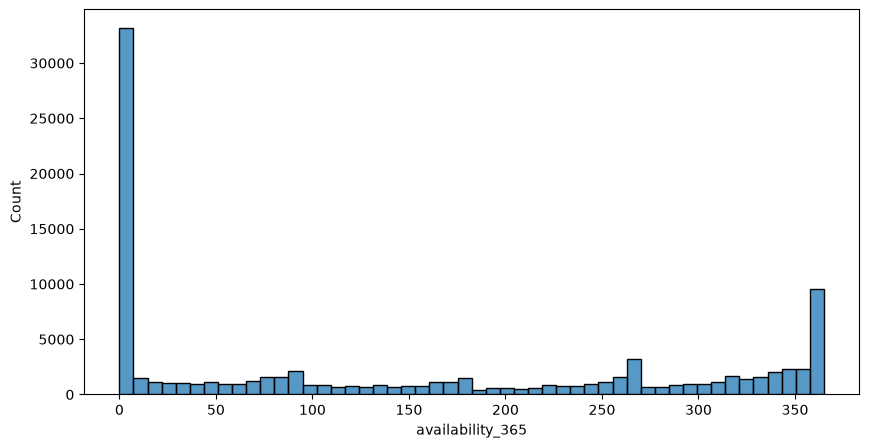

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["availability_365"],
    bins=50
)

plt.show()

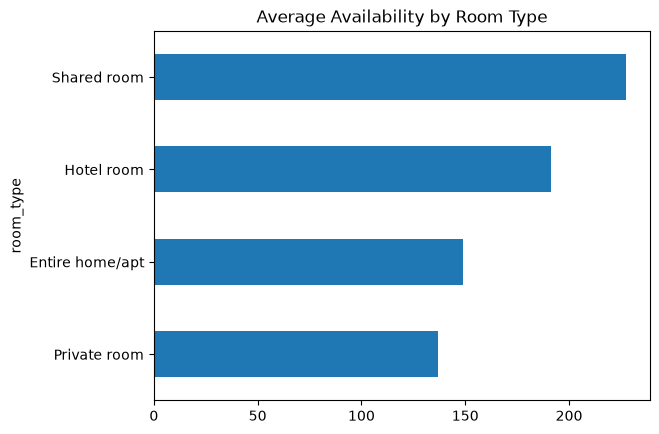

In [28]:
# Availability by Room Type

availability_room = (
    df.groupby("room_type")
    ["availability_365"]
    .mean()
    .sort_values()
)

availability_room.plot(
    kind="barh"
)

plt.title(
    "Average Availability by Room Type"
)

plt.show()

## 4.2 Geographic & Spatial Analysis

# Listing Density Across Neighbourhoods

In [32]:
import geopandas as gpd

gdf = gpd.read_file("../data/London/extracted/neighbourhoods.geojson")

gdf.head()

,neighbourhood,neighbourhood_group,geometry
0,Kingston upon Thames,None,"MULTIPOLYGON (((-0.33066 51.32901, -0.33057 51..."
1,Croydon,None,"MULTIPOLYGON (((-0.06399 51.31864, -0.06405 51..."
2,Bromley,None,"MULTIPOLYGON (((0.01216 51.2996, 0.01199 51.29..."
3,Hounslow,None,"MULTIPOLYGON (((-0.24454 51.4887, -0.24466 51...."
4,Ealing,None,"MULTIPOLYGON (((-0.41181 51.53408, -0.41186 51..."


In [33]:
# Count Listings Per Neighbourhood

density = (
    df.groupby("neighbourhood_cleansed")
    .size()
    .reset_index(name="listing_count")
)

In [34]:
gdf["neighbourhood"].head()

0    Kingston upon Thames
1                 Croydon
2                 Bromley
3                Hounslow
4                  Ealing
Name: neighbourhood, dtype: str

In [35]:
gdf_density = gdf.merge(
    density,
    left_on="neighbourhood",
    right_on="neighbourhood_cleansed",
    how="left"
)

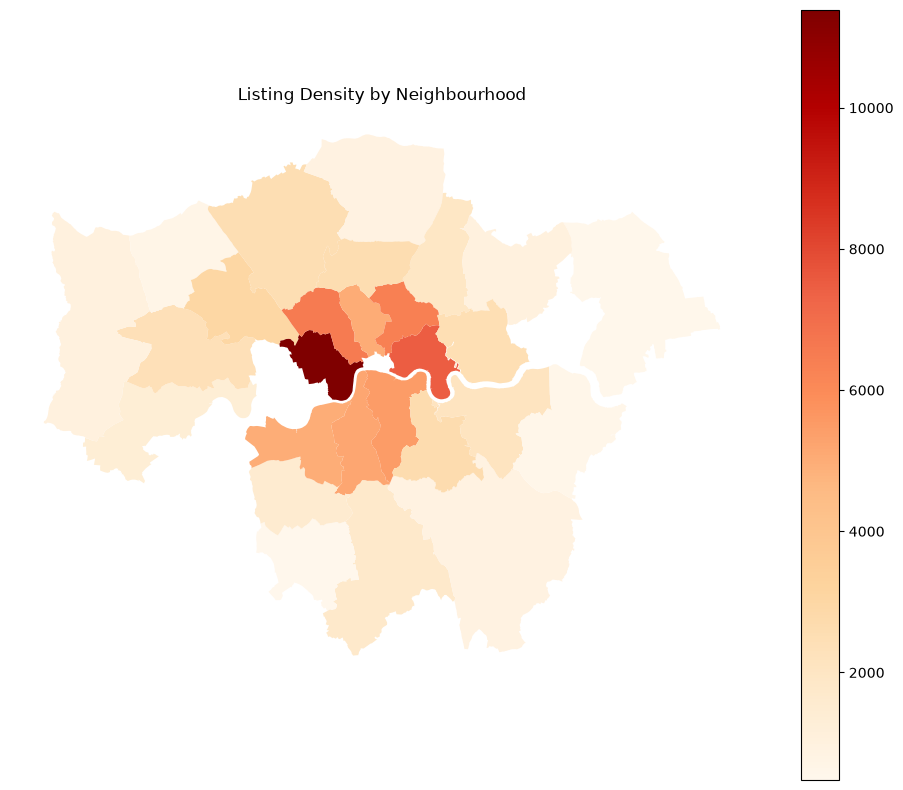

In [36]:
fig, ax = plt.subplots(
    figsize=(12,10)
)

gdf_density.plot(
    column="listing_count",
    cmap="OrRd",
    legend=True,
    ax=ax
)

plt.title(
    "Listing Density by Neighbourhood"
)

plt.axis("off")

plt.show()

# Geographic Pricing Gradient

In [37]:
# defining london center
city_lat = 51.5074
city_lon = -0.1278

In [38]:
from geopy.distance import geodesic

In [39]:
df["distance_to_center"] = df.apply(
    lambda row: geodesic(
        (row["latitude"], row["longitude"]),
        (city_lat, city_lon)
    ).km,
    axis=1
)

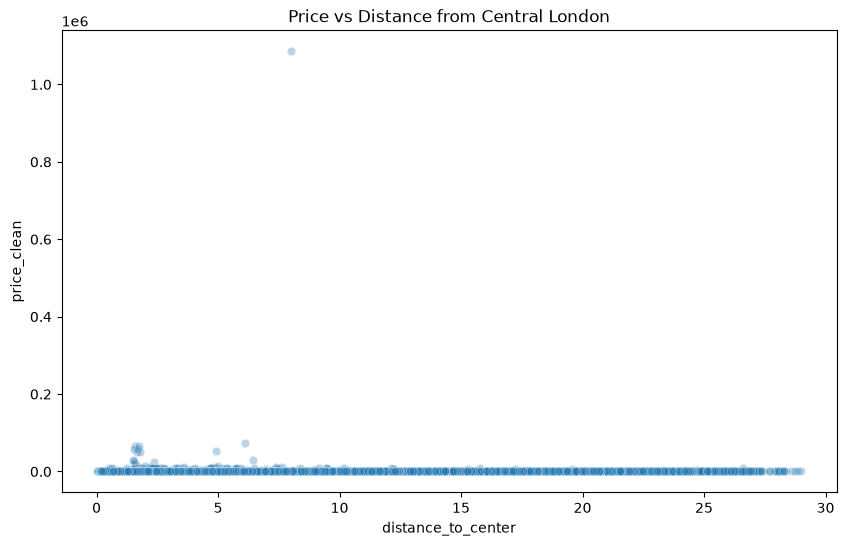

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="distance_to_center",
    y="price_clean",
    alpha=0.3
)

plt.title(
    "Price vs Distance from Central London"
)

plt.show()

In [41]:
# their correlation

df[
    ["distance_to_center", "price_clean"]
].corr()



,distance_to_center,price_clean
distance_to_center,1.00000,-0.01507
price_clean,-0.01507,1.00000


# Spatial Review Scores

In [43]:
# Neighbourhood Average Ratings

rating_map = (
    df.groupby("neighbourhood_cleansed")
    ["review_scores_rating"]
    .mean()
    .reset_index()
)

In [44]:
gdf_rating = gdf.merge(
    rating_map,
    left_on="neighbourhood",
    right_on="neighbourhood_cleansed",
    how="left"
)

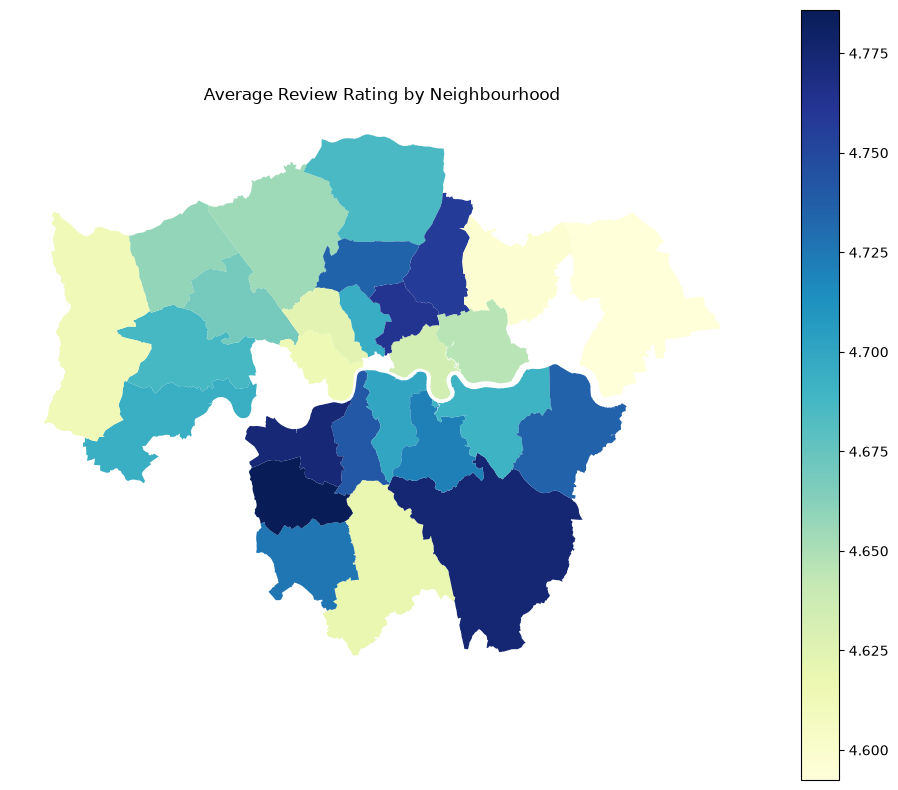

In [45]:
fig, ax = plt.subplots(
    figsize=(12,10)
)

gdf_rating.plot(
    column="review_scores_rating",
    cmap="YlGnBu",
    legend=True,
    ax=ax
)

plt.title(
    "Average Review Rating by Neighbourhood"
)

plt.axis("off")

plt.show()

# Property Type Clustering

In [46]:
df["room_type"].value_counts()

room_type
Entire home/apt    62907
Private room       33643
Shared room          212
Hotel room           109
Name: count, dtype: int64

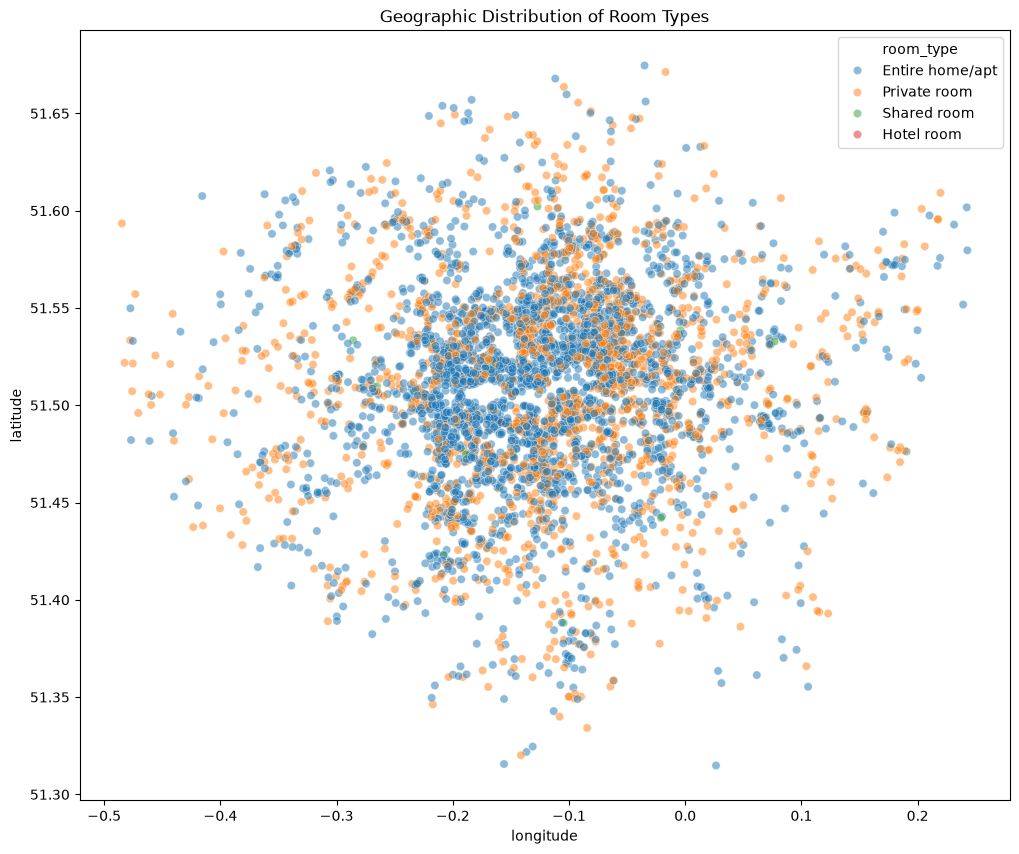

In [47]:
plt.figure(figsize=(12,10))

sns.scatterplot(
    data=df.sample(5000),
    x="longitude",
    y="latitude",
    hue="room_type",
    alpha=0.5
)

plt.title(
    "Geographic Distribution of Room Types"
)

plt.show()

In [48]:
# property types

top_props = (
    df["property_type"]
    .value_counts()
    .head(5)
    .index
)

In [49]:
property_map = df[
    df["property_type"].isin(top_props)
]

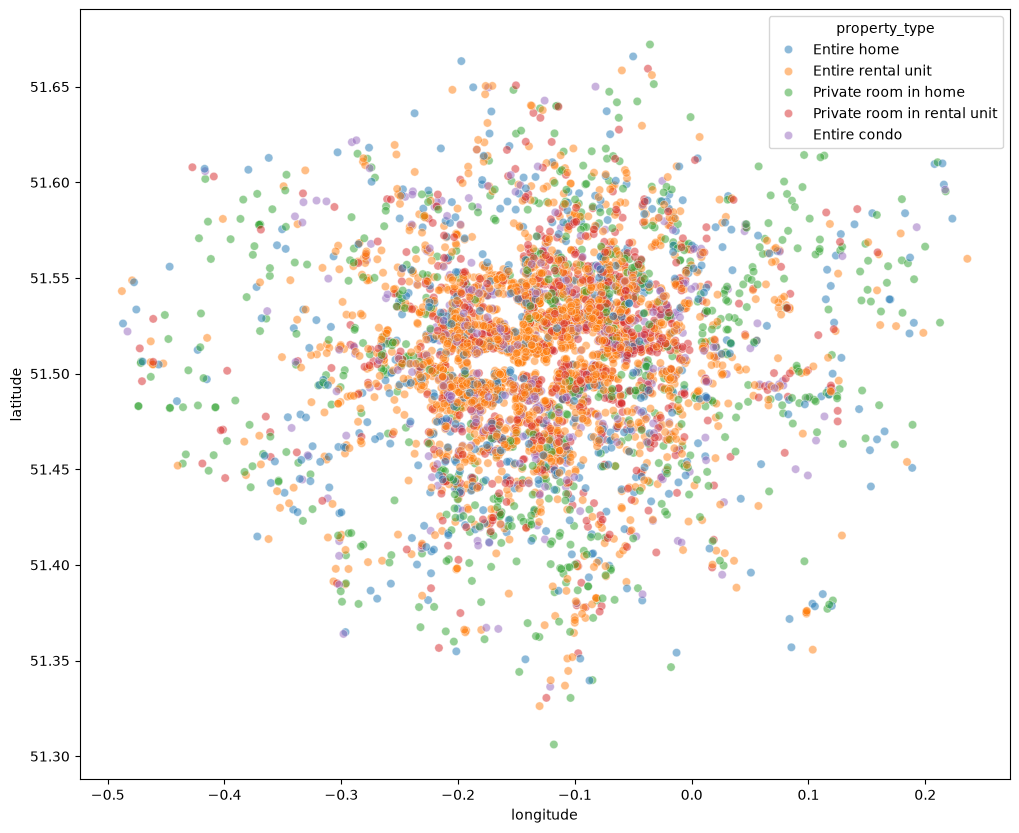

In [50]:
plt.figure(figsize=(12,10))

sns.scatterplot(
    data=property_map.sample(5000),
    x="longitude",
    y="latitude",
    hue="property_type",
    alpha=0.5
)

plt.show()

## 4.3 Temporal & Seasonal Trends 

# Review Trends Over Time

In [51]:
df_reviews_data = pd.read_csv("../data/London/cleaned/reviewsdata_clean.csv")

In [53]:
df_reviews_data["date"] = pd.to_datetime(
    df_reviews_data["date"]
)

In [57]:
# Aggregate Reviews by Month

monthly_reviews = (
    df_reviews_data
    .groupby(
        pd.Grouper(
            key="date",
            freq="ME"
        )
    )
    .size()
    .reset_index(name="review_count")
)

monthly_reviews.head()

,date,review_count
0,2009-12-31,1
1,2010-01-31,0
2,2010-02-28,0
3,2010-03-31,0
4,2010-04-30,0


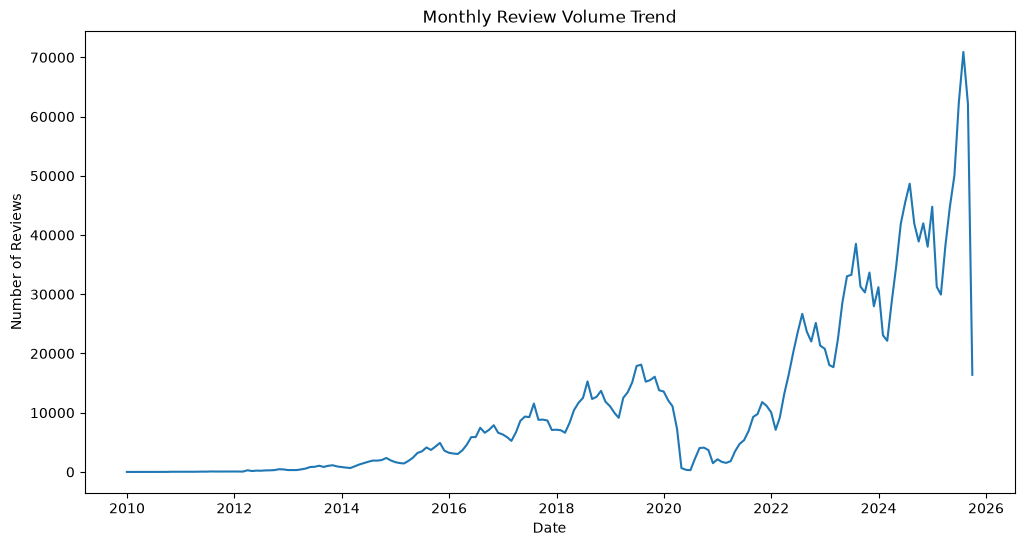

In [58]:
# Trend

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_reviews,
    x="date",
    y="review_count"
)

plt.title(
    "Monthly Review Volume Trend"
)

plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.show()

In [61]:
# Annual Trend

yearly_reviews = (
    df_reviews_data
    .groupby(
        df_reviews_data["date"].dt.year
    )
    .size()
    .reset_index(name="review_count")
)

yearly_reviews

,date,review_count
0,2009,1
1,2010,87
2,2011,698
3,2012,3048
4,2013,9154
5,2014,18640
6,2015,37748
7,2016,68172
8,2017,97118
9,2018,133514


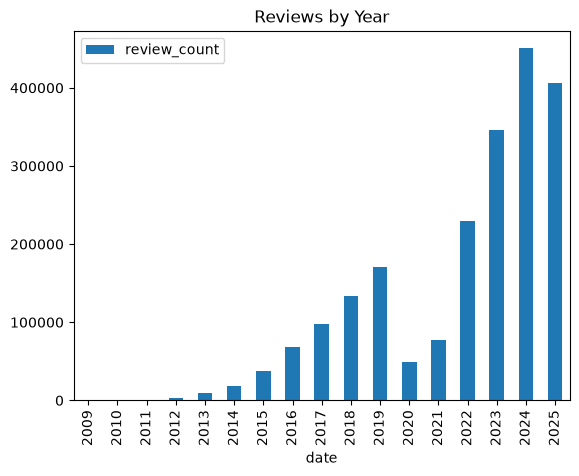

In [62]:
yearly_reviews.plot(
    x="date",
    y="review_count",
    kind="bar"
)

plt.title(
    "Reviews by Year"
)

plt.show()

# Host Tenure Analysis

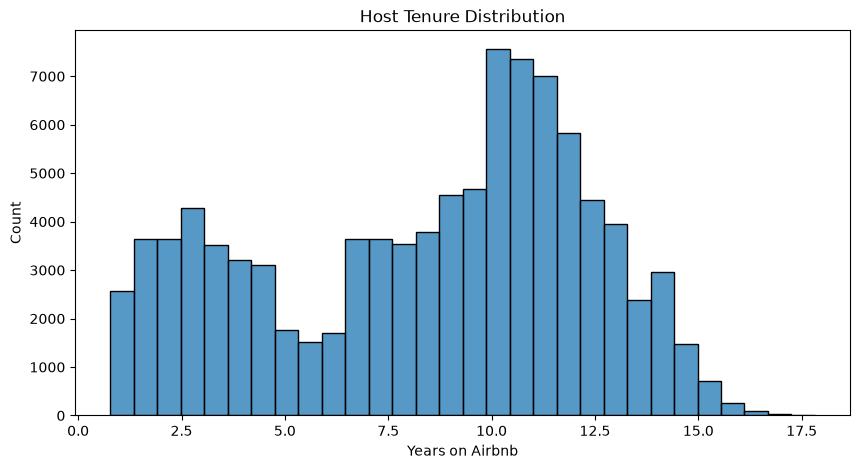

In [63]:
# Distribution of Host Tenure

plt.figure(figsize=(10,5))

sns.histplot(
    df["host_tenure_years"],
    bins=30
)

plt.title(
    "Host Tenure Distribution"
)

plt.xlabel(
    "Years on Airbnb"
)

plt.show()

In [64]:
df["host_tenure_years"].describe()

count    96830.000000
mean         8.411565
std          3.893562
min          0.780000
25%          4.830000
50%          9.340000
75%         11.350000
max         17.820000
Name: host_tenure_years, dtype: float64

In [65]:
# creating Tenure groups

df["host_tenure_group"] = pd.cut(
    df["host_tenure_years"],
    bins=[0,2,5,10,50],
    labels=[
        "New (<2 yrs)",
        "Experienced (2-5 yrs)",
        "Established (5-10 yrs)",
        "Veteran (10+ yrs)"
    ]
)

In [66]:
# Listings by Tenure Group

df["host_tenure_group"]\
    .value_counts()

host_tenure_group
Veteran (10+ yrs)         42179
Established (5-10 yrs)    29801
Experienced (2-5 yrs)     18080
New (<2 yrs)               6770
Name: count, dtype: int64

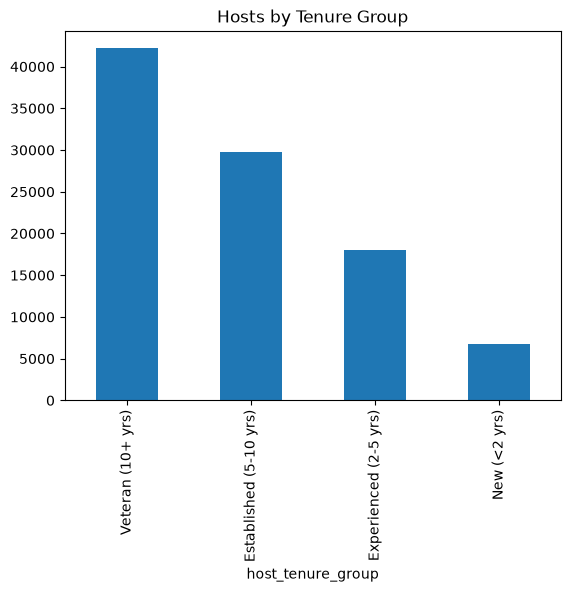

In [67]:
df["host_tenure_group"]\
    .value_counts()\
    .plot(kind="bar")

plt.title(
    "Hosts by Tenure Group"
)

plt.show()

In [68]:
# Price by Host Tenure

tenure_price = (  
    df.groupby("host_tenure_group")
    ["price_clean"]
    .mean()
)

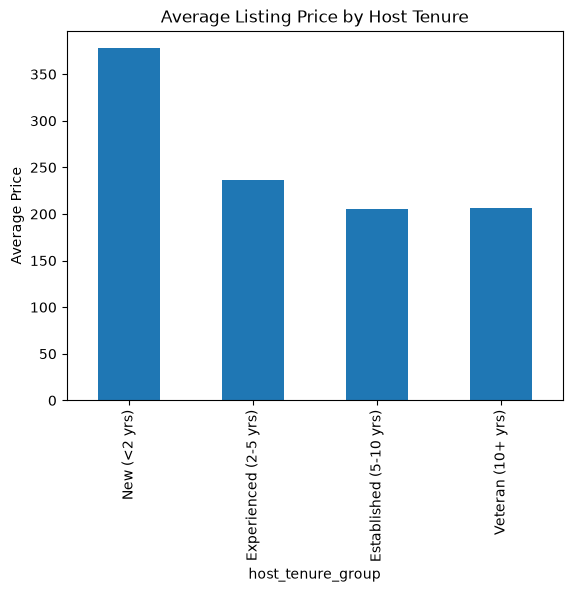

In [69]:
tenure_price.plot(
    kind="bar"
)

plt.title(
    "Average Listing Price by Host Tenure"
)

plt.ylabel(
    "Average Price"
)

plt.show()

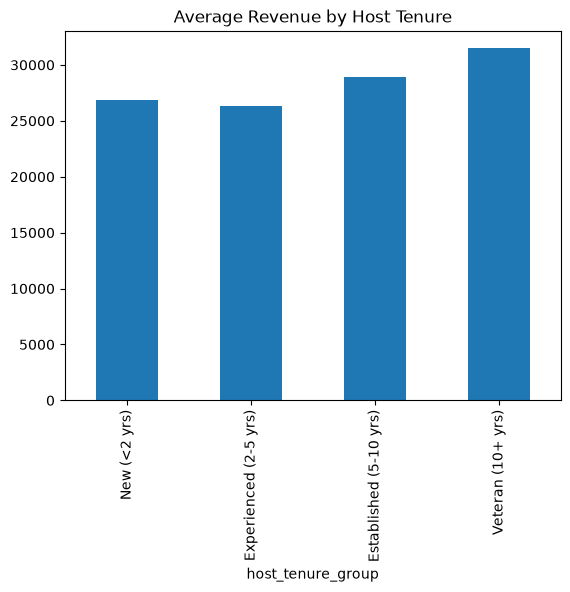

In [70]:
# Revenue by Host Tenure

tenure_revenue = (
    df.groupby("host_tenure_group")
    ["estimated_revenue"]
    .mean()
)

tenure_revenue.plot(
    kind="bar"
)

plt.title(
    "Average Revenue by Host Tenure"
)

plt.show()

In [71]:
# correlation

df[
    [
        "host_tenure_years",
        "price_clean"
    ]
].corr()

,host_tenure_years,price_clean
host_tenure_years,1.000000,-0.006992
price_clean,-0.006992,1.000000


## 4.4 Host & Supply-Side Analysis

# Host Segmentation

In [ ]:
# Calculating Listings Per Host

host_counts = (
    df.groupby("host_id")
    .size()
    .reset_index(name="listing_count")
)

host_counts.head()

,host_id,listing_count
0,2594,1
1,6774,6
2,9089,1
3,9323,1
4,9870,1


In [73]:
# Creating Segments

host_counts["host_segment"] = pd.cut(
    host_counts["listing_count"],
    bins=[0,1,5,20,float("inf")],
    labels=[
        "Single Listing",
        "Small Portfolio",
        "Professional",
        "Commercial"
    ]
)

In [74]:
# Segmenting Distribution

segment_counts = (
    host_counts["host_segment"]
    .value_counts()
)

segment_counts

host_segment
Single Listing     44875
Small Portfolio     8964
Professional        1486
Commercial           321
Name: count, dtype: int64

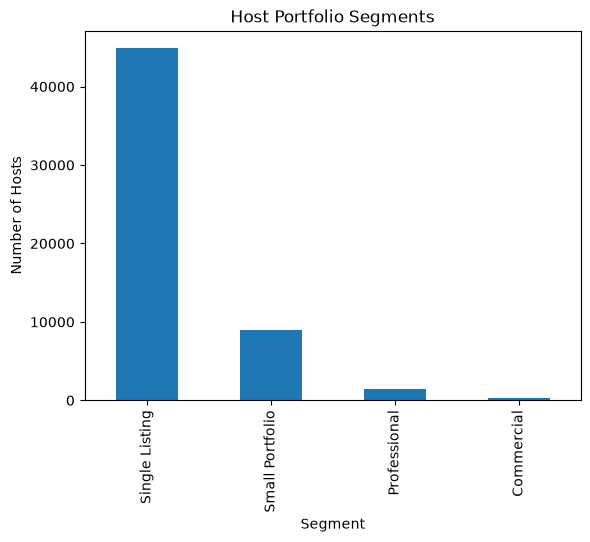

In [75]:
segment_counts.plot(
    kind="bar"
)

plt.title(
    "Host Portfolio Segments"
)

plt.xlabel("Segment")
plt.ylabel("Number of Hosts")

plt.show()

In [76]:
# Percentage Distribution

(
    host_counts["host_segment"]
    .value_counts(normalize=True)
    * 100
).round(2)

host_segment
Single Listing     80.64
Small Portfolio    16.11
Professional        2.67
Commercial          0.58
Name: proportion, dtype: float64

In [77]:
# Average Price by Segment

df_segment = df.merge(
    host_counts[
        ["host_id","host_segment"]
    ],
    on="host_id",
    how="left"
)

price_segment = (
    df_segment.groupby("host_segment")
    ["price_clean"]
    .mean()
)

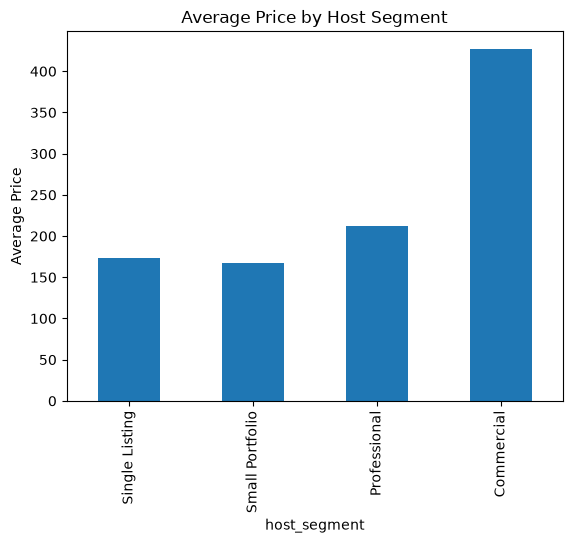

In [78]:
price_segment.plot(
    kind="bar"
)

plt.title(
    "Average Price by Host Segment"
)

plt.ylabel("Average Price")

plt.show()

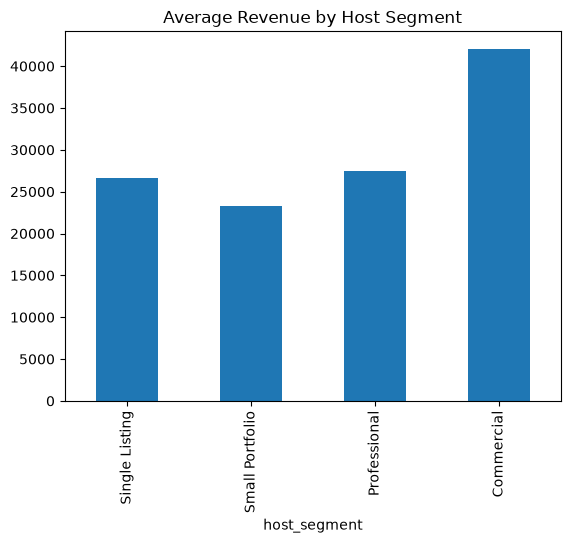

In [79]:
# Revenue by Segment

revenue_segment = (
    df_segment.groupby("host_segment")
    ["estimated_revenue"]
    .mean()
)

revenue_segment.plot(
    kind="bar"
)

plt.title(
    "Average Revenue by Host Segment"
)

plt.show()

# Superhost vs Non-Superhost

In [80]:
df["host_is_superhost"].value_counts()

host_is_superhost
f    77913
t    17192
Name: count, dtype: int64

<Axes: xlabel='host_is_superhost'>

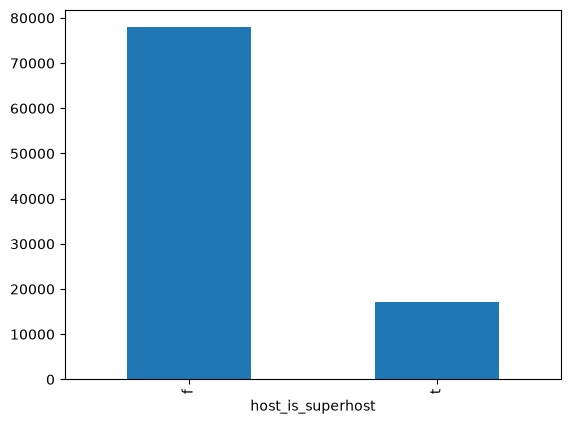

In [81]:
# Counting Hosts

df["host_is_superhost"]\
    .value_counts()

df["host_is_superhost"]\
    .value_counts()\
    .plot(kind="bar")

In [82]:
# Comparing Average Price

superhost_price = (
    df.groupby("host_is_superhost")
    ["price_clean"]
    .mean()
)

superhost_price

host_is_superhost
f    239.535463
t    202.029879
Name: price_clean, dtype: float64

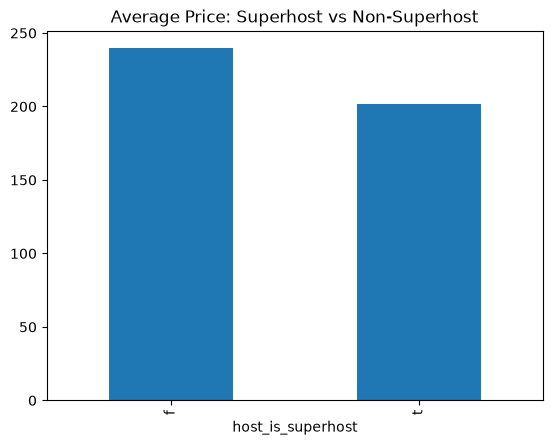

In [83]:
superhost_price.plot(
    kind="bar"
)

plt.title(
    "Average Price: Superhost vs Non-Superhost"
)

plt.show()

In [84]:
# Comparing Ratings

rating_comparison = (
    df.groupby("host_is_superhost")
    ["review_scores_rating"]
    .mean()
)

rating_comparison

host_is_superhost
f    4.637079
t    4.853570
Name: review_scores_rating, dtype: float64

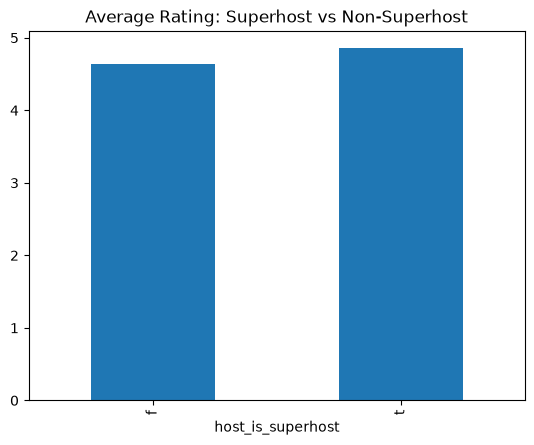

In [85]:
rating_comparison.plot(
    kind="bar"
)

plt.title(
    "Average Rating: Superhost vs Non-Superhost"
)

plt.show()

In [86]:
# comparing revenue

revenue_comparison = (
    df.groupby("host_is_superhost")
    ["estimated_revenue"]
    .mean()
)

revenue_comparison

host_is_superhost
f    27949.662352
t    31701.437138
Name: estimated_revenue, dtype: float64

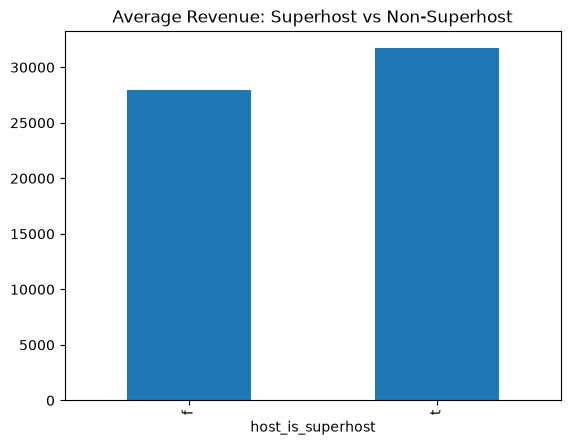

In [87]:
revenue_comparison.plot(
    kind="bar"
)

plt.title(
    "Average Revenue: Superhost vs Non-Superhost"
)

plt.show()

In [88]:
# Comparing Occupancy

occupancy_comparison = (
    df.groupby("host_is_superhost")
    ["occupancy_rate"]
    .mean()
)

occupancy_comparison

host_is_superhost
f    61.875852
t    53.177662
Name: occupancy_rate, dtype: float64

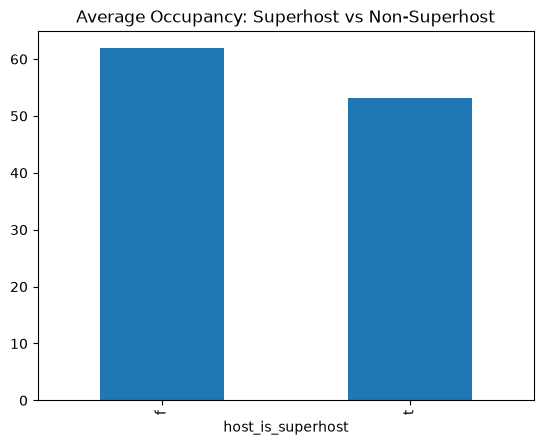

In [89]:
occupancy_comparison.plot(
    kind="bar"
)

plt.title(
    "Average Occupancy: Superhost vs Non-Superhost"
)

plt.show()

In [90]:
# statistical comparison

df.groupby(
    "host_is_superhost"
)[
    [
        "price_clean",
        "review_scores_rating",
        "occupancy_rate",
        "estimated_revenue"
    ]
].agg(
    ["mean","median"]
)

price_clean        review_scores_rating         \
                         mean median                 mean median   
host_is_superhost                                                  
f                  239.535463  133.0             4.637079   4.79   
t                  202.029879  143.0             4.853570   4.90   

                  occupancy_rate            estimated_revenue           
                            mean     median              mean   median  
host_is_superhost                                                       
f                      61.875852  76.438356      27949.662352  12972.0  
t                      53.177662  53.972603      31701.437138  17686.5

## 4.5 Review & Demand-Side Analysis 

# Price vs Reviews

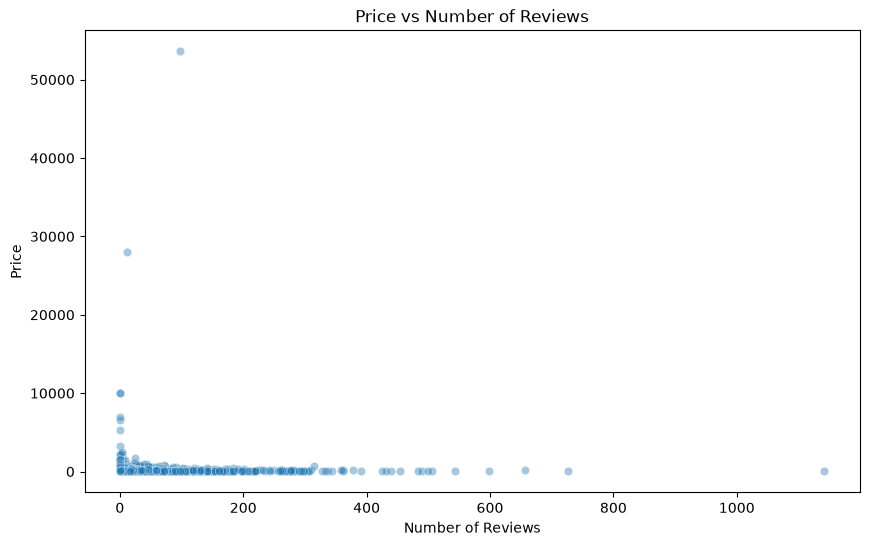

In [91]:
# Price vs Number of Reviews

sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="number_of_reviews",
    y="price_clean",
    alpha=0.4
)

plt.title(
    "Price vs Number of Reviews"
)

plt.xlabel("Number of Reviews")
plt.ylabel("Price")

plt.show()

In [92]:
df[
    ["price_clean", "number_of_reviews"]
].corr()

,price_clean,number_of_reviews
price_clean,1.000000,-0.006838
number_of_reviews,-0.006838,1.000000


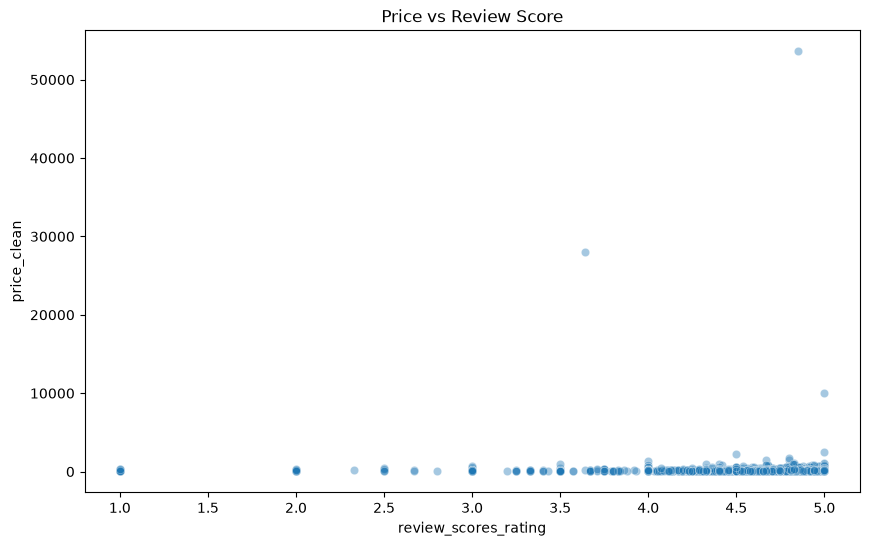

In [93]:
# Price vs Review Score

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="review_scores_rating",
    y="price_clean",
    alpha=0.4
)

plt.title(
    "Price vs Review Score"
)

plt.show()

In [94]:
df[
    ["price_clean", "review_scores_rating"]
].corr()

,price_clean,review_scores_rating
price_clean,1.000000,-0.012322
review_scores_rating,-0.012322,1.000000


In [95]:
# Average Price by Rating Band

# creating bands

df["rating_band"] = pd.cut(
    df["review_scores_rating"],
    bins=[0,4.0,4.5,4.8,5.0],
    labels=[
        "Below 4.0",
        "4.0-4.5",
        "4.5-4.8",
        "4.8-5.0"
    ]
)

In [96]:
rating_price = (
    df.groupby("rating_band")
    ["price_clean"]
    .mean()
)

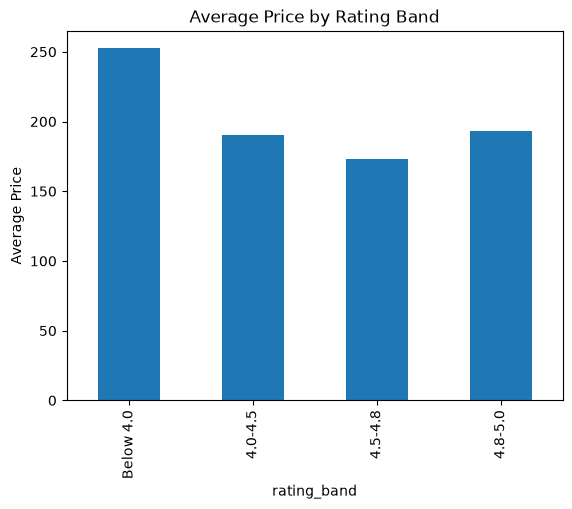

In [97]:
rating_price.plot(
    kind="bar"
)

plt.title(
    "Average Price by Rating Band"
)

plt.ylabel("Average Price")

plt.show()

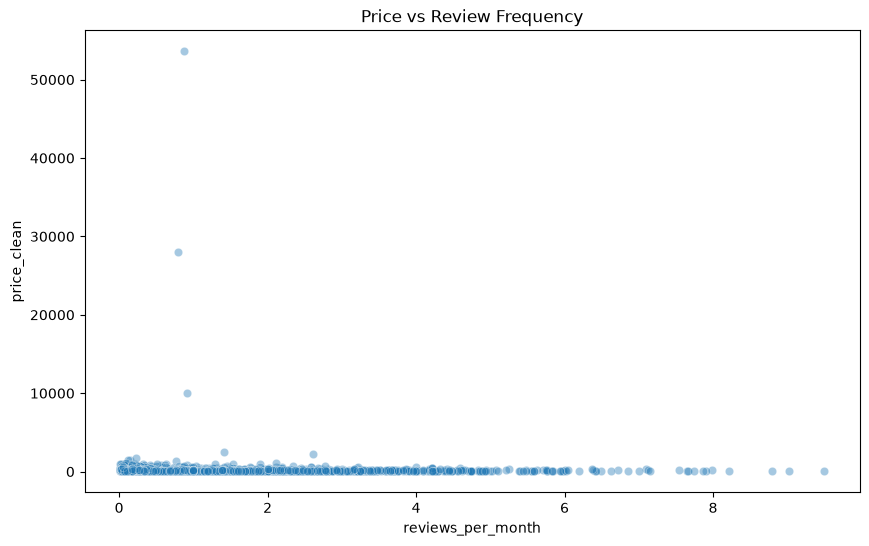

In [99]:
# Review Frequency as Demand Proxy

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="reviews_per_month",
    y="price_clean",
    alpha=0.4
)

plt.title(
    "Price vs Review Frequency"
)

plt.show()

In [100]:
df[
    ["price_clean", "reviews_per_month"]
].corr()

,price_clean,reviews_per_month
price_clean,1.000000,-0.022145
reviews_per_month,-0.022145,1.000000


# Review Score Sub-Dimensions

In [101]:
# Comparing Average Scores

subscores = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

subscore_summary = (
    df[subscores]
    .mean()
    .sort_values(ascending=False)
)

subscore_summary

review_scores_communication    4.812270
review_scores_checkin          4.790344
review_scores_location         4.729839
review_scores_accuracy         4.725514
review_scores_cleanliness      4.650038
review_scores_value            4.616202
dtype: float64

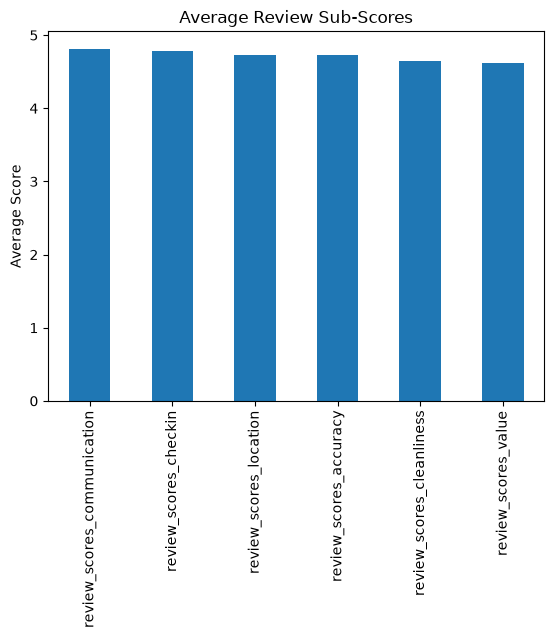

In [102]:
subscore_summary.plot(
    kind="bar"
)

plt.title(
    "Average Review Sub-Scores"
)

plt.ylabel("Average Score")

plt.show()

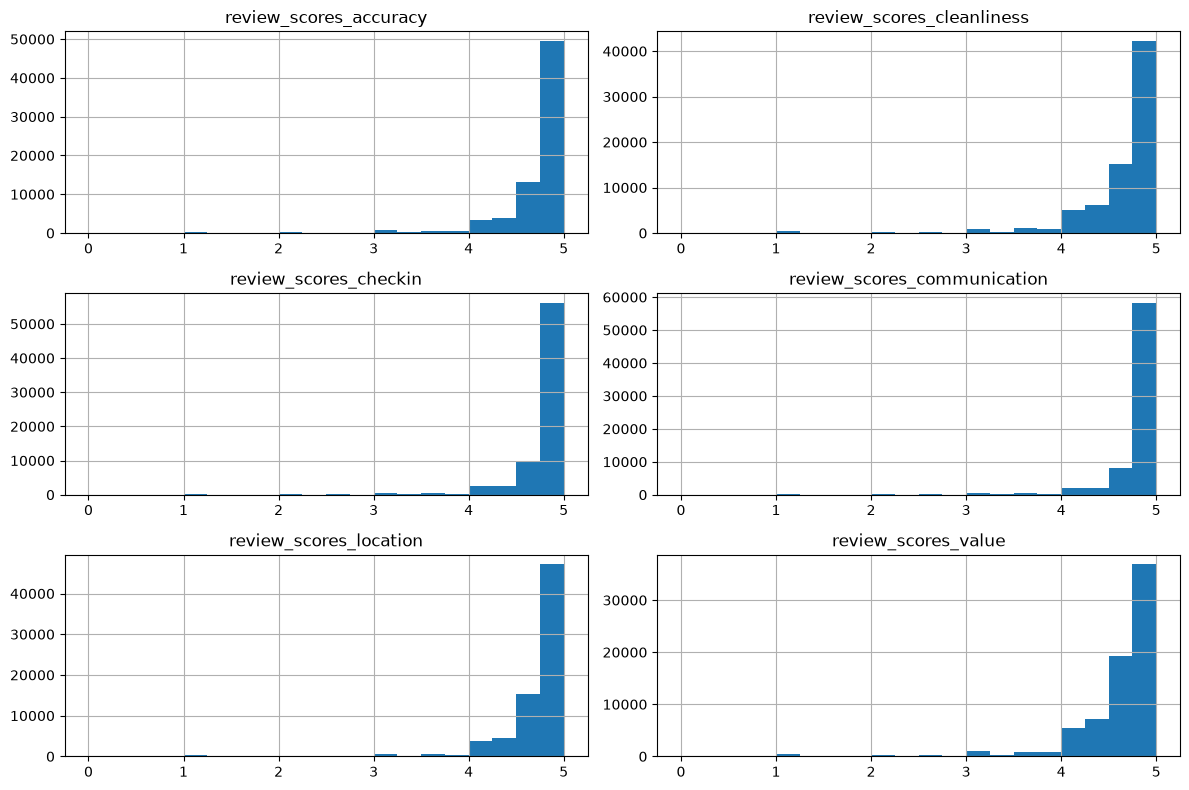

In [103]:
# Distribution of Each Subscore

df[subscores].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.show()

In [104]:
# Which Subscore Drives Overall Rating

corr_matrix = df[
    [
        "review_scores_rating",
        *subscores
    ]
].corr()

corr_matrix

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
review_scores_rating,1.000000,0.864879,0.803024,0.717864,0.786221,0.643298,0.873003
review_scores_accuracy,0.864879,1.000000,0.760979,0.698490,0.747293,0.633497,0.833617
review_scores_cleanliness,0.803024,0.760979,1.000000,0.613435,0.646877,0.564691,0.751569
review_scores_checkin,0.717864,0.698490,0.613435,1.000000,0.758438,0.570146,0.682087
review_scores_communication,0.786221,0.747293,0.646877,0.758438,1.000000,0.587834,0.747833
review_scores_location,0.643298,0.633497,0.564691,0.570146,0.587834,1.000000,0.640406
review_scores_value,0.873003,0.833617,0.751569,0.682087,0.747833,0.640406,1.000000


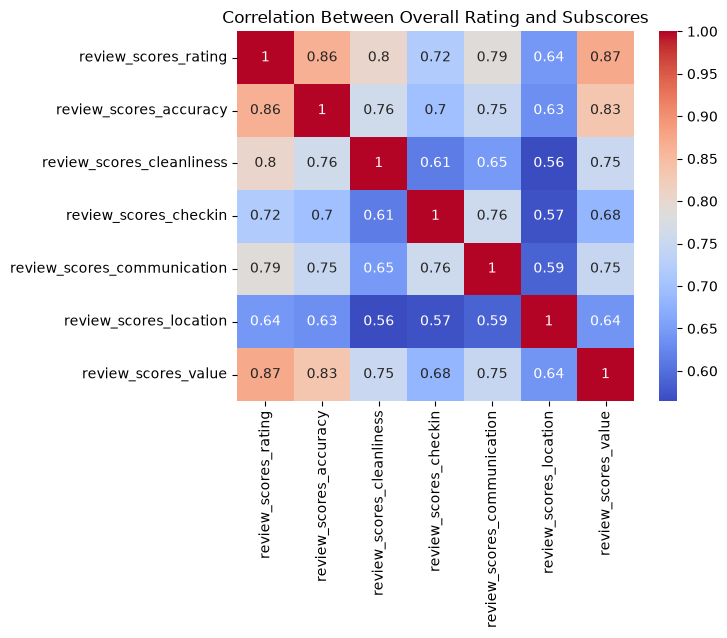

In [105]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Between Overall Rating and Subscores"
)

plt.show()

In [106]:
# Lowest Rated Listings

threshold = (
    df["review_scores_rating"]
    .quantile(0.10)
)

low_rated = df[
    df["review_scores_rating"] <= threshold
]

In [107]:
low_rated[subscores].mean()

review_scores_accuracy         3.802404
review_scores_cleanliness      3.710700
review_scores_checkin          4.130887
review_scores_communication    4.103682
review_scores_location         4.161744
review_scores_value            3.625129
dtype: float64

In [108]:
df[subscores].mean()

review_scores_accuracy         4.725514
review_scores_cleanliness      4.650038
review_scores_checkin          4.790344
review_scores_communication    4.812270
review_scores_location         4.729839
review_scores_value            4.616202
dtype: float64